# 네이버 카페 게시판 크롤러

## 필요 패키지 설치
```bash
pip install requests beautifulsoup4 pandas
```

## ⚠️ 주의사항
- 네이버 서비스 약관(ToS)을 준수하세요
- 과도한 요청은 IP 차단의 원인이 됩니다 (`delay` 설정 권장)
- 수집한 데이터는 개인 연구/분석 목적으로만 사용하세요

In [1]:
from naver_cafe_crawler import NaverCafeCrawler
import pandas as pd

# ==========================================
# 설정
# ==========================================
NAVER_ID  = "budongsin"
NAVER_PW  = "edgewater721"

CAFE_URL   = "https://cafe.naver.com/gugrade"  # 수집할 카페 URL
MENU_ID    = 491      # 게시판 메뉴 ID (0 = 전체글)
MAX_PAGES  = 3      # 수집할 최대 페이지 수
CONTENT_LIMIT = 10  # 본문을 가져올 게시글 수
DELAY      = 1.0    # 요청 간 딜레이 (초)
# ==========================================

In [ ]:
# [대안] 브라우저 쿠키 방식 — 2단계 인증 계정이거나 위 로그인이 실패한 경우 사용
# 개발자도구(F12) → Application → Cookies → naver.com 에서 복사
# 로그인 (ID/PW 방식)
#crawler = NaverCafeCrawler(delay=DELAY)
#crawler.login(NAVER_ID, NAVER_PW)

crawler = NaverCafeCrawler(delay=DELAY)
crawler.set_cookies(
     nid_aut="/taqHW5KZgjt8F5nJhrCOqCCRTiUaWGW0R007tfSaHCmfXseiR6aSkN/6kCeW9X/",
     nid_ses="AAABnkJrFh8NLjoKYgNeSp9Y1SmRks75KraQPP5qx897QszjUD3SnJSV/6gb5B+K9OThy3Yqw7Jiv78b80SHebnPTnhoy6X0elvvI9NmQKXmkcB1vaFHFKvbq5qw4EnsV2+D1bQwKbYlaEiIyvrA/FRTeKz9Vk7NRUmAeHKcmBiseqRIdCF0qOB+oxeELnl+04y1NP+HyDMzT1SPUxfXWwEiPBIYdE1yXbLHsXbNTWSxb6CNv9YFkYKbzsecfB/oqk7qzIMh/ubZ9cfroqSPpkVsizzNVnMZkN0MOpV0J0Z5G7KxPo4U/KUWe1Eh26WwbdT+unbgVtfBtftiskrrcZLEFKY4K+9d37904xOd8lpaW5hkggjM/jw5cHJeBnVAkkj0L2NLx4pPyObiBMP2DLwU5Io31dYDxWuWyC0lKPjnT0PU5NYvYZWqYW7Gv0kJBUwHQdgbXspYlPws8Nw0HYsiLaaWGKoasAraEaFcXBYx68v6tbUWzrPXxmrlig6l5YD6P292x4LOWo7wrm0bn8R/RF/MpicL6De7D4fvcT8VOdW+",
)

In [3]:
# 카페 정보 로드
crawler.load_cafe(CAFE_URL)

In [4]:
menus = crawler.get_menus()
print(len(menus))

630


In [5]:
menu_id = crawler.find_menu_id("국가직 9급 수다방", menus)
menu_id

'491'

In [ ]:
# 날짜 범위 지정 예시
#articles = crawler.get_articles(
#    menu_id=MENU_ID,
#    max_pages=100,          # 충분히 크게 설정
#    start_date='2026-03-01',
#    end_date='2026-03-31',
#)
results = crawler.search_articles(
    keywords=["PSAT", "핏셋"],
    max_pages=1,
    start_date='2025-01-01',
    end_date='2025-12-31',
)

pd.DataFrame(articles).head()

,article_id,title,author,date,view_count,comment_count,url
0,11744578,영어독해,,1774170711097,11,0,https://cafe.naver.com/gugrade/11744578
1,11744450,해커스 공무원,,1774138872507,11,0,https://cafe.naver.com/gugrade/11744450
2,11744325,"속초지역 단톡방 있는지 궁금한데, 준회원이라 내용을 볼 수 없어 아쉽네요.",,1774092185830,11,0,https://cafe.naver.com/gugrade/11744325
3,11744260,2027년 시험까지 패스 / 저랑 나눠서 들으실붐,,1774075291527,14,0,https://cafe.naver.com/gugrade/11744260
4,11744106,2026 이종하 회계학 전범위 기출변형 ​ 모의고사 구해요,,1774011122933,9,0,https://cafe.naver.com/gugrade/11744106


In [7]:
# 게시글 본문 수집
contents = crawler.get_article_contents(articles, limit=CONTENT_LIMIT)
print(f"본문 수집 완료: {len(contents)}개")

본문 수집 완료: 10개


In [8]:
pd.DataFrame(contents).head()

,article_id,title,author,date,view_count,comment_count,url,content,like_count,menu_name
0,11744578,영어독해,구나ㅇ,2026.03.22. 18:11,,0,https://cafe.naver.com/gugrade/11744578,9급 공무원 영어 독해 문제집 다들 뭐 쓰시나요?\n\n한책으로 돌리시나요 계속 새...,,국가직 9급 수다방
1,11744450,해커스 공무원,쏭맘s,2026.03.22. 09:21,,0,https://cafe.naver.com/gugrade/11744450,​\n\n​\n\nhttps://egosi.hackers.com/site/?c=ev...,,국가직 9급 수다방
2,11744325,"속초지역 단톡방 있는지 궁금한데, 준회원이라 내용을 볼 수 없어 아쉽네요.",즐겁고 신나,2026.03.21. 20:23,,0,https://cafe.naver.com/gugrade/11744325,"9급 지방직 사회복지사 관련 시험을 알게 됐습니다. \n\n3월말에 접수던데, 이번...",,국가직 9급 수다방
3,11744260,2027년 시험까지 패스 / 저랑 나눠서 들으실붐,히삐해삐,2026.03.21. 15:41,,0,https://cafe.naver.com/gugrade/11744260,50만원/ 오전~ 5시 /5시~저녁 \n\n타임 나눠서 들으실분 구해요! 두타임중 ...,,국가직 9급 수다방
4,11744106,2026 이종하 회계학 전범위 기출변형 ​ 모의고사 구해요,멘토스ㄱㄱ,2026.03.20. 21:52,,0,https://cafe.naver.com/gugrade/11744106,​\n\nㄴㅅㅌ 패스가지고계신분께 pdf자료 구해봅니다\n\n2026 국가직 파이널...,,국가직 9급 수다방


In [13]:
pd.DataFrame(contents).to_csv('contents.csv')

In [10]:
# 댓글 수집
comments = crawler.get_all_comments(articles, limit=CONTENT_LIMIT)
print(f"댓글 수집 완료: {len(comments)}개")

댓글 수집 완료: 16개


In [14]:
pd.DataFrame(comments).to_csv('comments.csv')

In [16]:
_contents = pd.read_csv('contents.csv')
_comments = pd.read_csv('comments.csv')
_comments

,Unnamed: 0,article_id,comment_id,author,content,date,like_count,is_reply
0,0,11743571,123614286,찹츄리버,"교육행정도 많이 하고, 워라밸등 같은걸로 계리직도 많이 지원하는것 같아요",NaN,NaN,False
1,1,11743571,123616447,월요일알러지,적성도 많이 보시는 거 같고 티오도 많이 고려하시는 거 같아요 ㅎㅎ,NaN,NaN,False
2,2,11743571,123626558,맛있는과일,전공과목이랑 자격증이 겹치는 곳이 있다면 그게 1순위고 그 다음은 합격 가능성과 적...,NaN,NaN,False
3,3,11743571,123648372,영이영잉,"저도 결혼, 자녀 계획있어서 워라벨 나은 교행으로 생각하구있어요 ㅎㅎ",NaN,NaN,False
4,4,11743339,123606486,ReadyGo,"솔직히 말씀드리면, 22년에는 행정법이 선택과목이어서 지금보다 엄청 쉬웠습니다.\n...",NaN,NaN,False
5,5,11743339,123606686,치킨냠냠이,네..? 2022 엄청 어려웠다고 하던데..,NaN,NaN,True
6,6,11743339,123606737,ReadyGo,"아 죄송합니다.. 선택과목은 21년까지였네요..\n행정법은 75점이고, 나마지 4과...",NaN,NaN,True
7,7,11743339,123606875,치킨냠냠이,맞아요ㅠㅠ 저두 그렇게 생각해요.. 지방직을 노려야겠죠ㅠ 나머지 과목들은 다 자신 ...,NaN,NaN,True
8,8,11743339,123606956,ReadyGo,그래도 다른 과목 점수가 나오신다니 다행이네요.. 모쪼록 행운을 빕니다,NaN,NaN,True
9,9,11743339,123607025,치킨냠냠이,감사합니당 ㅎㅎ,NaN,NaN,True


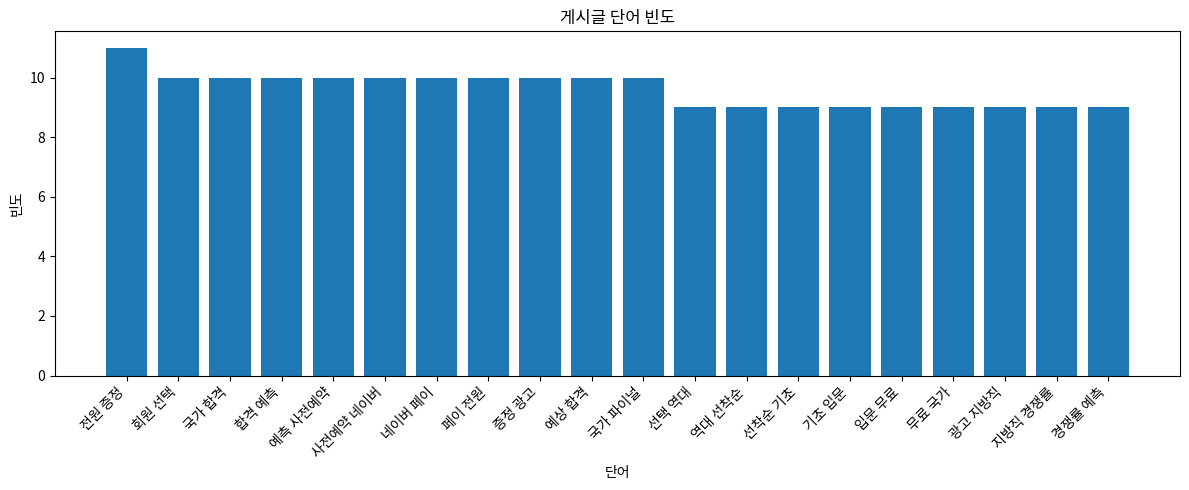

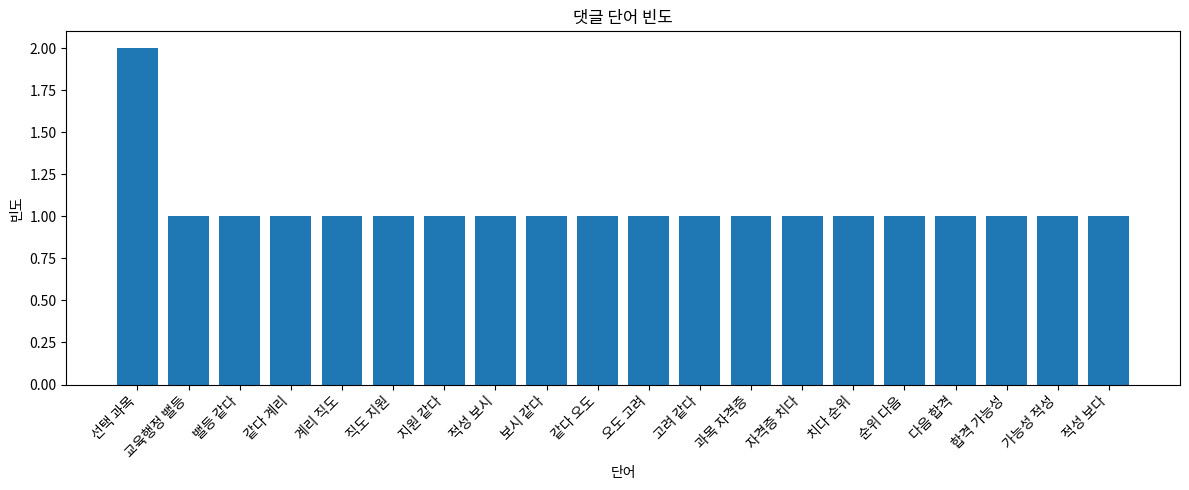

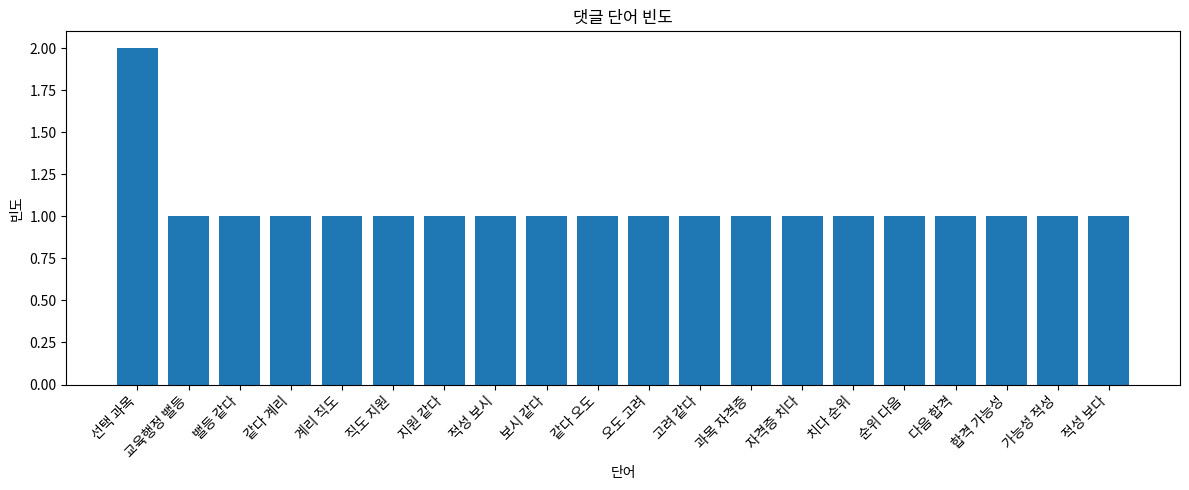

In [ ]:
from text_analyzer import TextAnalyzer
import pandas as pd

analyzer = TextAnalyzer()

# 게시글 분석
articles_df = pd.read_csv('contents.csv')
article_freq = analyzer.analyze_articles(articles_df, keyword=["PSAT","핏셋"])  # title + content 기본
#print(article_freq.head(20))

# 댓글 분석
comments_df = pd.read_csv('comments.csv')
comment_freq = analyzer.analyze_comments(comments_df, keyword=["PSAT","핏셋"])
#print(comment_freq.head(20))

# 시각화
analyzer.plot_bar(article_freq, top_n=20, title='게시글 단어 빈도',save_pdf='article_freq.pdf')
analyzer.plot_bar(comment_freq, top_n=20, title='댓글 단어 빈도',save_pdf='comment_freq.pdf')
#analyzer.plot_wordcloud(comment_freq, title='댓글 워드클라우드')